In [17]:
import matplotlib.pyplot as plt
import numpy as np
import random
from timeskip_diffuser.diffuser.nets import EqNet, TemporalUNet
from timeskip_diffuser.diffuser.trainer import DiffuserTrainer
from timeskip_diffuser.diffuser.diffusion import GaussianDiffusion
from timeskip_diffuser.diffuser.planner import DiffuserPlanner, expand_spline_from_skip_list
from timeskip_diffuser.diffuser.reward import CompositeReward, GoalReachingReward, PathLengthPenalty, StartReachingReward, TotalTimeSkipPenalty, CurvaturePenalty, LogSkipReward
from timeskip_diffuser.datasets.point_maze.offline_skip.offline_skip import OfflineSkipDataset
import torch

In [36]:
dataset = OfflineSkipDataset(file_path="C:\\Users\\ianh\\Documents\\Code\\rpmml\\rpmml-project\\timeskip-diffuser\\src\\timeskip_diffuser\\datasets\\offline_datasets\\medium_h32_mu1_sig1.npz", dataset_id="D4RL/pointmaze/medium-v2", horizon=160)

In [37]:
len(dataset)

395375

In [38]:
net_type = "eqnet"

match net_type:
    case "eqnet":
        net_class = EqNet
        ckpt = "C:\\Users\\ianh\\Documents\\Code\\rpmml\\rpmml-project\\timeskip-diffuser\\src\\timeskip_diffuser\\pipelines\\runs\\medium_eqnet_skip_seed0_20251221_131741\\checkpoints\\diffuser_eqnet_epoch_20.pt"
    case "unet":
        net_class = TemporalUNet
        ckpt = "..."

In [39]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = net_class(
    state_dim=dataset.state_dim+1,
    time_dim=32,
)
diffusion = GaussianDiffusion(timesteps=200)
trainer = DiffuserTrainer(model, diffusion, dataset, lr=1e-4, device=device)
trainer.load_checkpoint(ckpt)
planner = DiffuserPlanner(model, diffusion, dataset, device=device)

Using device: cuda


(32, 2)
(32, 1)


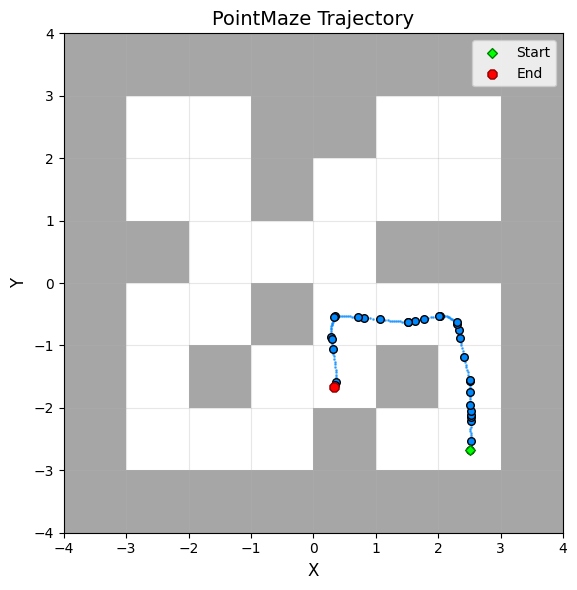

In [40]:
traj_norm = random.choice(dataset)
traj = dataset.denormalize(traj_norm)
dataset.visualize(traj)

In [49]:
current = np.array([1.5, -2.5]) # traj[0][:2].copy()
goal = np.array([-2, 2]) # traj[-1][:2].copy()
print(current, goal)

[ 1.5 -2.5] [-2  2]


In [53]:
reward_fn = CompositeReward([
        StartReachingReward(current, reward_scale=5.0),
        GoalReachingReward(goal, reward_scale=5.0),
        TotalTimeSkipPenalty(reward_scale=0.0),
        CurvaturePenalty(reward_scale=0.05),
        LogSkipReward(reward_scale=0.0),
])

traj_model = planner.plan_and_reconstruct(
    current,
    goal,
    reward_fn=reward_fn,
    horizon=64,
    guidance_scale=1.0,
    condition_on_start=True,
    condition_on_goal=True,
    conditioning_schedule="constant",
    conditioning_strength=0.9,
    spline_func=expand_spline_from_skip_list,
)["coarse"]
print(traj_model)
print(f"Start (actual): {traj_model[0, :2]}")
print(f"Start (target): {current[:2]}")
print(f"Start error: {np.linalg.norm(traj_model[0, :2] - current[:2]):.4f}")
print(f"End: {traj_model[-1, :2]}")
print(f"Goal: {goal}")
print(f"Goal error: {np.linalg.norm(traj_model[-1, :2] - goal):.4f}")

# Check for discontinuities (physics violations)
diffs = np.linalg.norm(traj_model[1:, :2] - traj_model[:-1, :2], axis=1)
max_jump = diffs.max()
print(f"Max step size: {max_jump:.4f}")
if max_jump > 0.2:  # Adjust threshold based on your maze
    print("  ⚠️  WARNING: Large discontinuity detected!")
else:
    print("  ✓ Trajectory appears continuous")

[[ 1.600377   -2.4945223   0.914289  ]
 [ 1.581962   -2.5315773   2.4303415 ]
 [ 1.6980098  -2.5319724   4.7593174 ]
 [ 1.7802559  -2.538852    5.0223007 ]
 [ 1.9443678  -2.5391328   4.4513855 ]
 [ 2.1333137  -2.5687847   5.3448243 ]
 [ 2.3460083  -2.5690796  18.073435  ]
 [ 2.4040978  -2.3028457   9.765039  ]
 [ 2.361451   -1.9507942   8.084217  ]
 [ 2.3135903  -1.6175325   6.112772  ]
 [ 2.2982228  -1.3408427   4.2202997 ]
 [ 2.2955258  -1.1190901   2.7238903 ]
 [ 2.2998993  -0.96357894  2.7809007 ]
 [ 2.3021278  -0.8310531   3.6685834 ]
 [ 2.300815   -0.7034      9.971807  ]
 [ 2.1817777  -0.5639116   6.4733787 ]
 [ 1.9729916  -0.56452644  4.417899  ]
 [ 1.7664789  -0.5935345   4.641138  ]
 [ 1.57228    -0.6199527   5.236035  ]
 [ 1.3806918  -0.62894106  5.3781757 ]
 [ 1.1762418  -0.61294127  3.7077882 ]
 [ 0.99287343 -0.6001607   3.4709406 ]
 [ 0.81447315 -0.5844858   1.9135056 ]
 [ 0.728289   -0.5798302   2.4282062 ]
 [ 0.6292447  -0.57767177  1.9549603 ]
 [ 0.56035244 -0.5777777 

In [54]:
traj_model.shape

(64, 3)

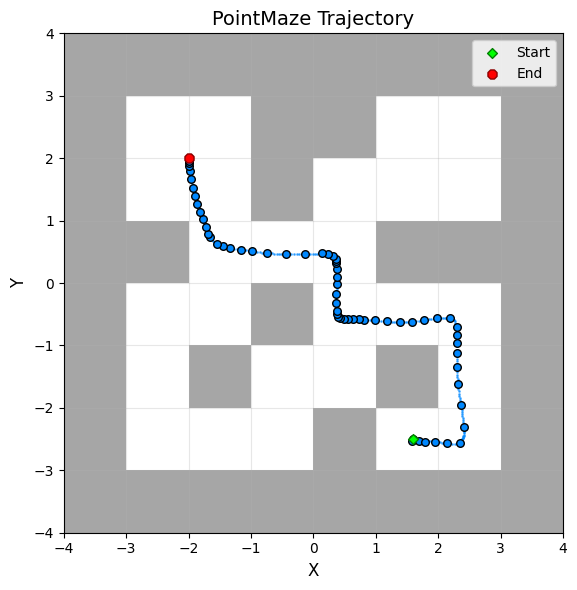

In [55]:
dataset.visualize(traj_model)